KulingNet - Cloud Image Classifier
- Based on: CCSN dataset, contains 2543 cloud images. 
- According to the World Meterological Organization’s genera-based classification recommendation, we divide into 11 different categories：

Ci = cirrus; 
Cs = cirrostratus; 
Cc = cirrocumulus; 
Ac = altocumulus; 
As = altostratus; 
Cu = cumulus; 
Cb = cumulonimbus; 
Ns = nimbostratus; 
Sc = stratocumulus; 
St = stratus; 
Ct = contrail.


All images are fixed resolution 256×256 pixels with the JPEG format.

-----------------------------------------------------------------------


In [26]:
# General Imports 
import numpy as np
# import pandas as pd
import os 
from pathlib import Path 
import random
import math

# For image processing
from PIL import Image
from IPython.display import Image as showIMG

# Pytorch 
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

# Torchvision
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision import models
from torchmetrics import Precision, Recall
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

# Plotting
import matplotlib.pyplot as plt

# Sklearn
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

Torch: 2.9.0+cu126
Torchvision: 0.24.0+cu126


In [27]:
# Running on GPU
print(torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Device specs
if str(device) == 'cuda':
    devNumber = torch.cuda.current_device()
    print(f"Current device number: {devNumber}")
    devName = torch.cuda.get_device_name()
    print(f"GPU name is {devName}")

device

2.9.0+cu126
Current device number: 0
GPU name is NVIDIA GeForce RTX 3060 Ti


device(type='cuda')

In [28]:
# Where we are right now, absolute pathing  
base_dir = os.path.abspath('')
images_file_path = os.path.join(base_dir, "CCSN_Image_set")
# example path for cirrus clouds
ci_file_path = os.path.join(images_file_path, "Ci")

print(f"Example (Cirrus) filepath: {ci_file_path}")
print(f"Root filepath: {images_file_path}")

pathData = Path(images_file_path)

Example (Cirrus) filepath: c:\Users\Admin\Documents\Chalmers\Programmering\KulingNet\CCSN_Image_set\Ci
Root filepath: c:\Users\Admin\Documents\Chalmers\Programmering\KulingNet\CCSN_Image_set


In [29]:
# Overview of images
def walkDataset(dir_path):
    directories = []
    image_count = 0
    for dirpath, dirnames, filenames in os.walk(dir_path):
        directories.append(dirpath)
        image_count += len(filenames)
        print(f"There are {len(filenames)} " + "images in " + dirpath[73:])    
    print(f"Total image count: {image_count}")
    return directories

image_dir_paths = walkDataset(images_file_path)


There are 0 images in 
There are 221 images in Ac
There are 188 images in As
There are 242 images in Cb
There are 268 images in Cc
There are 139 images in Ci
There are 287 images in Cs
There are 200 images in Ct
There are 182 images in Cu
There are 274 images in Ns
There are 340 images in Sc
There are 202 images in St
Total image count: 2543


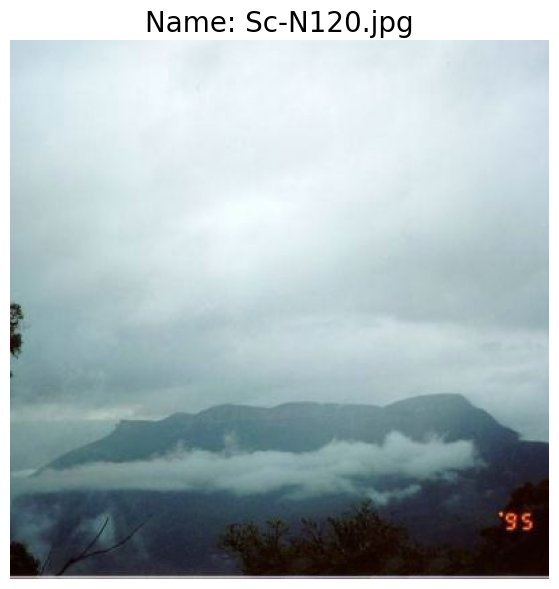

In [30]:
# Plot random image with class label

# Test path
# random_image_path = ci_file_path +  "\Ci-N001.jpg"
random.seed()

# Random image folder in directory
random_image_dir_path = random.choice(image_dir_paths)
# List of images in that folder
filenames = os.listdir(random_image_dir_path)
# Random image in the folder
random_image = random.choice(filenames)
# Absolute path to image 
random_image_path = os.path.join(random_image_dir_path, random_image)

def plotImage(imagePath_str):
    imagePath = Path(imagePath_str)
    #image_class = imagePath.stem
    img = Image.open(imagePath)
    # Access only the name
    img_name = imagePath_str[len(imagePath_str)-11:]

    # For plotting
    img_as_array = np.asarray(img)
    
    plt.figure(figsize=(10,7))
    plt.imshow(img_as_array)
    plt.title(f"Name: {img_name}", fontsize=20)
    plt.axis(False)

plotImage(random_image_path)

In [31]:
# Tensor ~ vector (array of components)
# Compose allows for list of several transformations simultanously 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((227,227)),
    
    # Adjusts with mean=0.5, stdv=0.5 
    # 3 Channels because of RGB (Greyscale would be 1 channel)
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),

    # Data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.RandomCrop(size=227, padding=10),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)
])

# Create the full dataset
full_dataset = datasets.ImageFolder(root=images_file_path, transform=transform)
# Example image size
full_dataset[0][0].size()


torch.Size([3, 227, 227])

In [32]:
# Labels
class_names = ["altocumulus", "altostratus", "cumulonimbus", "cirrocumulus", 
               "cirrus", "cirrostratus", "contrail", "cumulus", "nimbostratus", 
               "stratocumulus", "stratus"]


In [33]:
# Train, test split
train_data, test_data = torch.utils.data.random_split(full_dataset,[0.8,0.2])

train_loader = torch.utils.data.DataLoader(train_data, batch_size=8, shuffle=True, num_workers=2)
# No shuffling since no training is done, randomness not needed
test_loader = torch.utils.data.DataLoader(train_data, batch_size=8, shuffle=False, num_workers=2)

#full_dataset.class_to_idx

# Get split data 
"""
X_train = [full_dataset[i][0] for i in train_data.indices]
X_val = [full_dataset[i][0] for i in test_data.indices]
y_val = [full_dataset[i][1] for i in test_data.indices]
y_train = [full_dataset[i][1] for i in train_data.indices]

"""

'\nX_train = [full_dataset[i][0] for i in train_data.indices]\nX_val = [full_dataset[i][0] for i in test_data.indices]\ny_val = [full_dataset[i][1] for i in test_data.indices]\ny_train = [full_dataset[i][1] for i in train_data.indices]\n\n'

torch.Size([3, 227, 227])
Cloud type: cirrostratus, label: 5


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24661148..1.0000005].


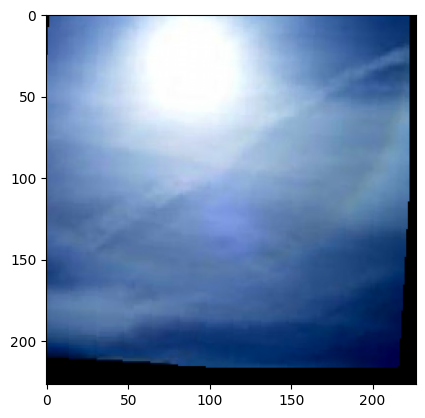

In [34]:
image, label = train_data[5]
# 3 channel 32x32 images
print(image.size())
# Print name???
print(f"Cloud type: {class_names[label]}, label: {label}")

image = image.squeeze().permute(1, 2, 0)

plt.imshow(image)
plt.show()

In [ ]:
# Output size: (input size - kernel + 2*padding) / stride + 1
def conv_output_shape(h_w, kernel_size=1, stride=1, pad=0, dilation=1):
    if type(kernel_size) is not tuple:
        kernel_size = (kernel_size, kernel_size)
    h = math.floor( ((h_w[0] + (2 * pad) - ( dilation * (kernel_size[0] - 1) ) - 1 )/ stride) + 1)
    w = math.floor( ((h_w[1] + (2 * pad) - ( dilation * (kernel_size[1] - 1) ) - 1 )/ stride) + 1)
    return h, w

class KulingNet(nn.Module):
    # Create base nn-architecture
    def __init__(self, num_classes=11):
        super().__init__()
        self.name = "KulingNet"  

        # Maxpool2d: Pools together 2x2 pixels to single pixel 
        # (extracts important features), out_channels double after each pooling
        self.features = nn.Sequential(
            # Input: 3x227x227 -> output size: (227 - 11 + 2*0) /  4 + 1 = 55 -> 96x55x55
            # cl1, 96x55x55
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, padding=0, stride=4),
            # No batch normalization????
            #nn.BatchNorm2d(32),
            nn.ReLU(),
            # pooling reduces dimension with 2
            nn.MaxPool2d(kernel_size=3, stride=2), # 96x27x27

            # cl2, output: 256x27x27
            nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, padding=2, stride=1),
            #nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2), # 256x13x13

            # cl3 and cl4 are grouped together, as they have the same dimensionality
            # cl3, output: 256x13x13
            nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, padding=1, stride=1),
            #nn.BatchNorm2d(128),
            nn.ReLU(),
            # No pooling, features are hard to extract

            # cl4, 256x13x13
            nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, padding=1, stride=1),
            #nn.BatchNorm2d(256),
            nn.ReLU(),

            # cl5
            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, padding=1, stride=1),
            #nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2) # 256x6x6
        )

        # Adaptive pooling for flexibility, determine output size regardless of input
        #self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # "Dense" layers, neurons have to be compatible, but chosen freely
        self.fc = nn.Sequential(
            # fc1, 9216 input features
            nn.Linear(in_features=256*6*6, out_features=4096),
            nn.ReLU(),
            # Reduce overfitting by "turning off" neurons randomly, rate depends on data size
            # this small <3000 images needs strong regularization (NOTE data aug also regularizes)
            nn.Dropout(0.5),

            # fc2
            nn.Linear(in_features=4096, out_features=num_classes)
        )
    
    def forward(self, x):
        # Pass through convolutional layers
        x = self.features(x)
        #print(x.shape)
        x = torch.flatten(x, 1)
        #print(x.shape)
        # Pass through fully connected layers
        x = self.fc(x)

        return x


In [ ]:
# Train one epoch
def train_one_epoch(net, dataloader, loss_function, optimizer):
    # Set to training mode
    net.train()
    # Metrics for evaluation
    running_loss = 0.0
    correct = 0 
    total = 0

    for data in dataloader:
        images, labels = data
        # For running on GPU
        images, labels = images.to(device), labels.to(device) 
        
        optimizer.zero_grad()
        outputs = net(images)

        # Calculate difference of predicted vs actual labels
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        # Update loss, scaled by batch size
        running_loss += loss.item() * images.size(0)

        # Accuracy 
        _ , preds = torch.max(outputs, 1)
        correct += (preds==labels).sum().item() 
        total += labels.size(0)
    
    # Update metrics
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total

    # 
    print(f"Running train loss: {running_loss / len(dataloader.dataset):.4f}")

    return epoch_loss, epoch_acc

In [60]:
# Validate one epoch
def validate_one_epoch(net, dataloader, loss_function):
    # For confusion matrix
    y_true, y_pred = [], []

    precision = Precision(task="multiclass", num_classes=11, average="weighted").to(device)
    recall = Recall(task="multiclass", num_classes=11, average="weighted").to(device)

    # Set network to evaluation mode
    net.eval()

    # Metrics for evaluation
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            # For running on GPU
            images, labels = images.to(device), labels.to(device) 

            # Feed images through network
            outputs = net(images)
            
            # calculate difference between predicted & true labels
            loss = loss_function(outputs, labels)

            # Update loss per data point
            running_loss += loss.item() * images.size(0)

            # Accuracy 
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Compute metrics
            precision(preds,labels)
            recall(preds,labels)

            # For confusion matrix
            y_true.extend(labels)
            y_pred.extend(preds)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, y_true, y_pred, correct, total, precision, recall


In [61]:
net = KulingNet()
net = net.to(device)

loss_function = nn.CrossEntropyLoss()
# lr: step size during gradient descent
# momentum: using past gradients (inertia)
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum=0.9)

# For reducing learning rate along the way
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=10)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Training loop
EPOCHS = 3
for epoch in range(EPOCHS):
    print("Epoch:", epoch+1, "...")

    train_loss, train_acc = train_one_epoch(net, train_loader, loss_function, optimizer)
    val_loss, val_acc, y_true, y_pred, val_correct, val_total, precision, recall = validate_one_epoch(net, test_loader, loss_function)

    # Count epochs for scheduler
    scheduler.step()

    # Add Loss & Validation for each epoch to lists of total
    train_accuracies.append(train_acc)
    train_losses.append(train_loss)
    val_accuracies.append(val_acc)
    val_losses.append(val_loss)

# For confusion matrix
#y_true = np.array(y_true)
#y_pred = np.array(y_pred)

# Compute total Precision, Recall & Accuracy metrics
prec_score = precision.compute()
rec_score = recall.compute()
accuracy = 100 * val_correct / val_total

print(f"Accuracy: {accuracy:.3f} %",
    f"Precision Score: {prec_score:.3f}",
    f"Recall Score: {rec_score:.3f}",
    sep="\n"
)

Epoch: 1 ...
Running train loss: 2.3893
Epoch: 2 ...
Running train loss: 2.3562
Epoch: 3 ...
Running train loss: 2.2727
Accuracy: 18.182 %
Precision Score: 0.087
Recall Score: 0.182


In [71]:
# Save net parameters
# saved_net_dir = base_dir + "\\Trained_models"
print(base_dir)
#torch.save(net.state_dict(), base_dir + "\\KulingNet3.0_trained.pth")

c:\Users\Admin\Documents\Chalmers\Programmering\KulingNet


In [ ]:
# Load net with parameters
net = KulingNet()
# Load from other directory
net.load_state_dict(torch.load(base_dir + "\\KulingNet3.0_trained.pth"))

<All keys matched successfully>

In [ ]:
# Confusion Matrix
def get_confusion_matrix(y_true, y_pred):
    print(type(y_pred))
    # 11 Unique output classes
    labels = [x for x in range(11)]
    # Normalize to get percentages

    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    
    display_labels = list(full_dataset.class_to_idx.keys())
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues, values_format=".2f")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True Label")
    plt.show()

    return cm

cm = get_confusion_matrix(y_true, y_pred)

<class 'list'>


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [68]:
# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report: \n", report) 

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

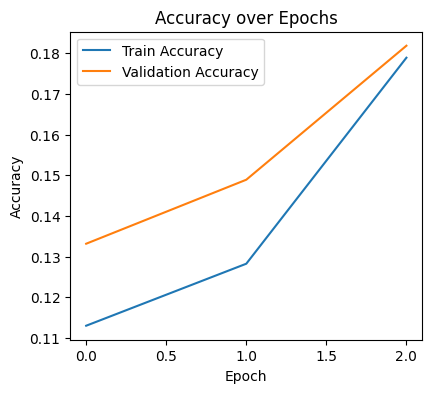

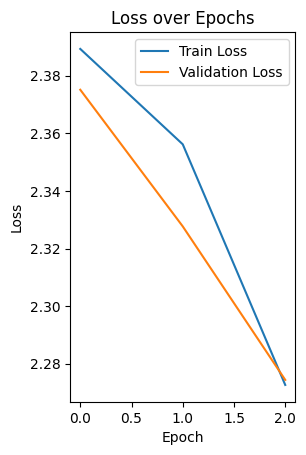

[2.3892690816733997, 2.3561644881011814, 2.2726607457425727]

In [69]:
# Plot Accuracy 
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

train_losses

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Pred: nimbostratus, Label: ?


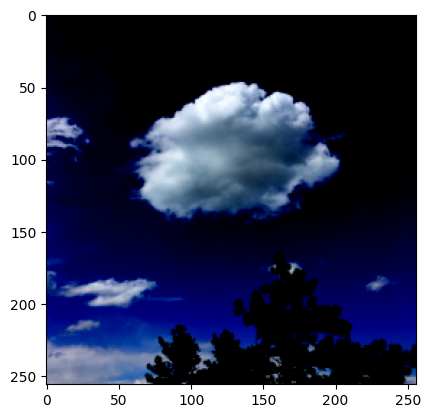

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Pred: nimbostratus, Label: ?


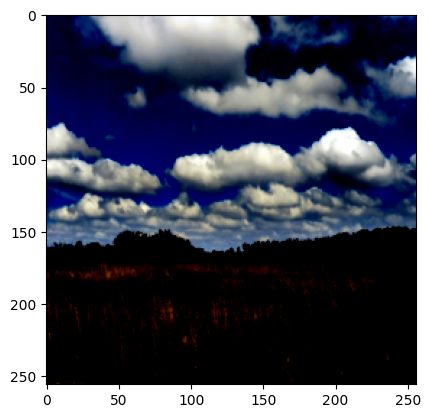

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Pred: cumulus, Label: ?


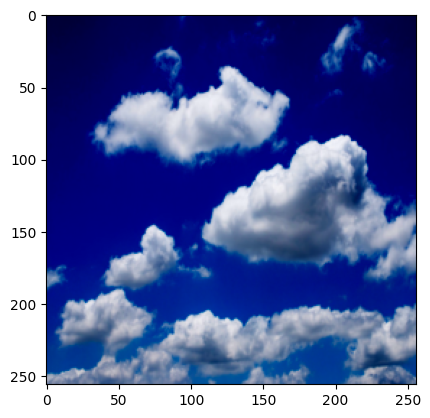

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Pred: cumulonimbus, Label: ?


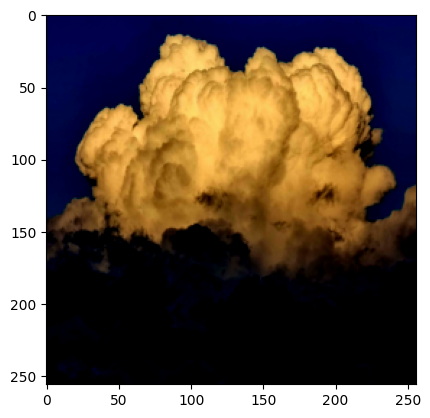

In [ ]:
# Transform test images with different format 
new_transform = transforms.Compose([
    #transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
    transforms.Resize((256,256)),
])

# Helper function
def load_image(path):
    image = Image.open(path)
    image = new_transform(image)
    # Add batch dimension
    image = image.unsqueeze(0)
    return image

# Pathing
test_images_file_path = os.path.join(base_dir, "Testing_Images")
test_images_list = os.listdir(test_images_file_path)

# Visual 
img = Image.open(test_images_file_path + '\\Cu_1.jpg')
#plt.imshow(img)
#plt.show()

# Images as tensors, only Cumulus
images = [load_image(test_images_file_path + "\\" + img) for img in test_images_list]

def test_example_images():
    # Set to evaluation mode
    net.eval()
    # No gradient descent, as no training occurs
    with torch.no_grad():
        for image in images:
            output = net(image)
            _, predicted = torch.max(output,1)
            print(f"Pred: {class_names[predicted.item()]}, Label: ?")
            image = image.squeeze().permute(1, 2, 0)
            plt.imshow(image)
            plt.show()

test_example_images()
